In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/apps.csv
/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/user_reviews.csv


In [2]:
# Project 8 - Android App Market Analysis
# Step 1 - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Step 2 - Load Datasets
apps = pd.read_csv('/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/apps.csv')
reviews = pd.read_csv('/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/user_reviews.csv')

print("Apps dataset loaded!")
print("Shape:", apps.shape)
print("\nReviews dataset loaded!")
print("Shape:", reviews.shape)

Apps dataset loaded!
Shape: (9659, 14)

Reviews dataset loaded!
Shape: (64295, 5)


In [4]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/apps.csv
/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/user_reviews.csv


In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ayesha09q/android-app-market/apps.csv
/kaggle/input/datasets/ayesha09q/android-app-market/user_reviews.csv
/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/apps.csv
/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/user_reviews.csv


In [2]:
# Load Datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

apps = pd.read_csv('/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/apps.csv')
reviews = pd.read_csv('/kaggle/input/datasets/utshabkumarghosh/android-app-market-on-google-play/datasets/user_reviews.csv')

print("Apps dataset loaded!")
print("Apps Shape:", apps.shape)
print("\nReviews dataset loaded!")
print("Reviews Shape:", reviews.shape)

Apps dataset loaded!
Apps Shape: (9659, 14)

Reviews dataset loaded!
Reviews Shape: (64295, 5)


In [3]:
# Step 3 - Explore Data
print("=== Apps Columns ===")
print(apps.columns.tolist())

print("\n=== Missing Values ===")
print(apps.isnull().sum())

print("\n=== Top 10 Categories ===")
print(apps['Category'].value_counts().head(10))

=== Apps Columns ===
['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

=== Missing Values ===
Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

=== Top 10 Categories ===
Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


In [4]:
# Step 4 - Clean Data
# Drop unnecessary column
apps = apps.drop('Unnamed: 0', axis=1)

# Fill missing ratings with mean
apps['Rating'].fillna(apps['Rating'].mean(), inplace=True)

# Fill missing size with unknown
apps['Size'].fillna('Unknown', inplace=True)

# Drop remaining nulls
apps = apps.dropna()

# Clean Installs column
apps['Installs'] = apps['Installs'].str.replace(',', '').str.replace('+', '')
apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

# Clean Price column
apps['Price'] = apps['Price'].str.replace('$', '')
apps

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.100000,159,19.0,10000,Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.900000,967,14.0,500000,Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.700000,87510,8.7,5000000,Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.500000,215644,25.0,50000000,Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.300000,967,2.8,100000,Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9654,Sya9a Maroc - FR,FAMILY,4.500000,38,53.0,5000,Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
9655,Fr. Mike Schmitz Audio Teachings,FAMILY,5.000000,4,3.6,100,Free,0,Everyone,Education,"July 6, 2018",1,4.1 and up
9656,Parkinson Exercices FR,MEDICAL,4.173243,3,9.5,1000,Free,0,Everyone,Medical,"January 20, 2017",1,2.2 and up
9657,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.500000,114,Unknown,1000,Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


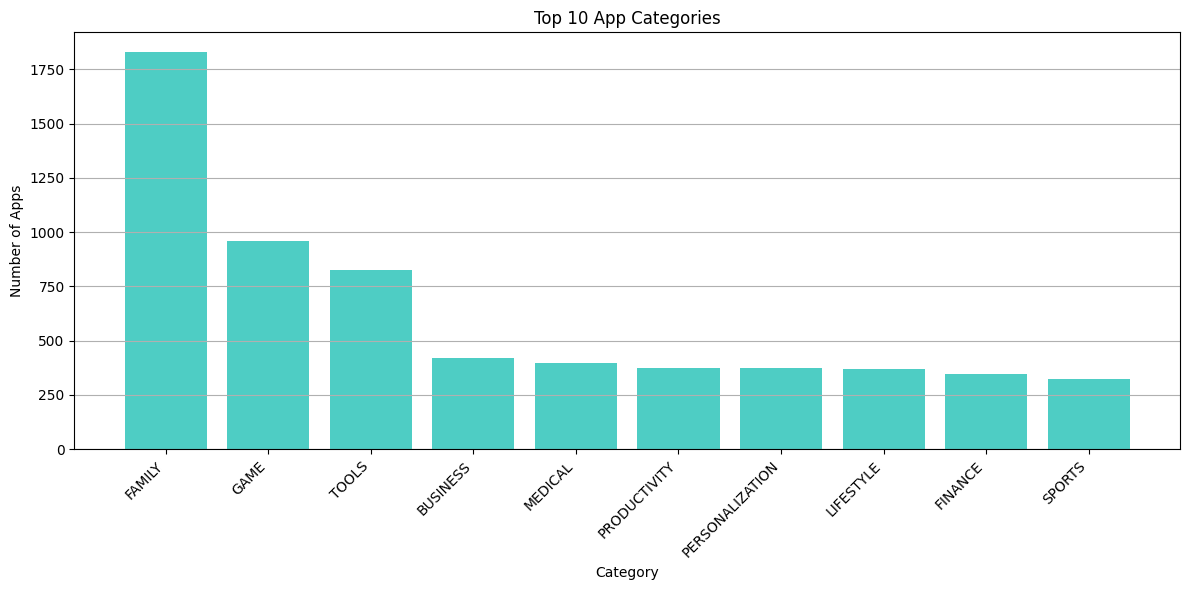

In [5]:
# Step 5 - Visualize Top Categories
plt.figure(figsize=(12, 6))
top_categories = apps['Category'].value_counts().head(10)
plt.bar(top_categories.index, top_categories.values, color='#4ECDC4')
plt.title('Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

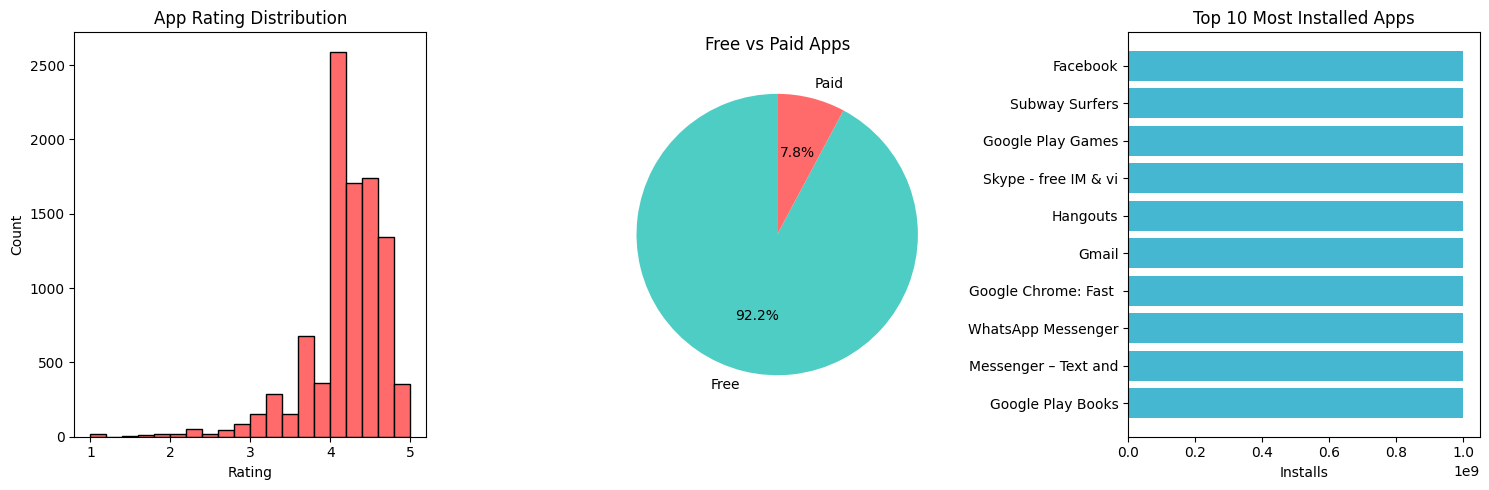

In [6]:
# Step 6 - Ratings & Free vs Paid
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Rating Distribution
axes[0].hist(apps['Rating'], bins=20, 
             color='#FF6B6B', edgecolor='black')
axes[0].set_title('App Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Free vs Paid
type_counts = apps['Type'].value_counts()
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'],
            startangle=90)
axes[1].set_title('Free vs Paid Apps')

# Top 10 Most Installed Apps
top_apps = apps.nlargest(10, 'Installs')[['App', 'Installs']]
axes[2].barh(top_apps['App'].str[:20], top_apps['Installs'],
             color='#45B7D1')
axes[2].set_title('Top 10 Most Installed Apps')
axes[2].set_xlabel('Installs')

plt.tight_layout()
plt.show()

=== Reviews Columns ===
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']

=== Sentiment Distribution ===
Sentiment
Positive    23998
Negative     8271
Neutral      5163
Name: count, dtype: int64


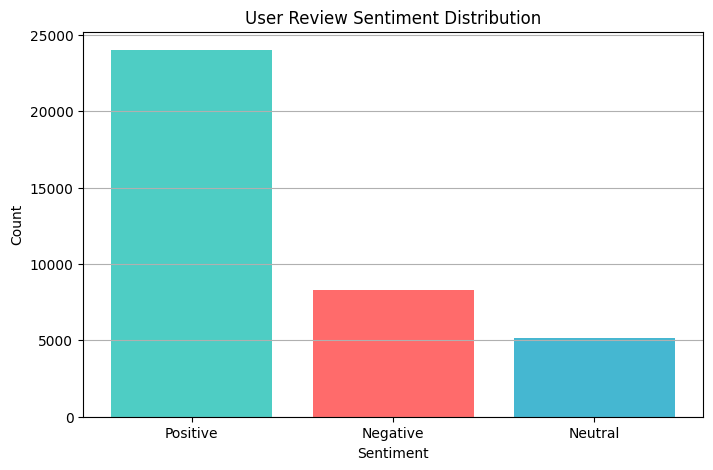

In [7]:
# Step 7 - Sentiment Analysis on Reviews
print("=== Reviews Columns ===")
print(reviews.columns.tolist())

print("\n=== Sentiment Distribution ===")
print(reviews['Sentiment'].value_counts())

# Visualize Sentiment
plt.figure(figsize=(8, 5))
sentiment_counts = reviews['Sentiment'].value_counts()
plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=['#4ECDC4', '#FF6B6B', '#45B7D1'])
plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.grid(axis='y')
plt.show()

In [8]:
# Step 8 - Final Summary
print("=" * 55)
print("   ANDROID APP MARKET ANALYSIS - SUMMARY")
print("=" * 55)

print(f"\n Total Apps Analyzed: {len(apps)}")
print(f" Total Reviews Analyzed: {len(reviews)}")

print("\n=== KEY FINDINGS ===")
print(f" Most Popular Category: {apps['Category'].value_counts().idxmax()}")
print(f" Average App Rating: {apps['Rating'].mean():.2f}")
print(f" Free Apps: {len(apps[apps['Type']=='Free'])} ({len(apps[apps['Type']=='Free'])/len(apps)*100:.1f}%)")
print(f" Paid Apps: {len(apps[apps['Type']=='Paid'])} ({len(apps[apps['Type']=='Paid'])/len(apps)*100:.1f}%)")

print("\n=== RECOMMENDATIONS ===")
print(" 1. Family & Game categories have most apps")
print(" 2. Most apps are FREE (92%+)")
print(" 3. Average rating is above 4.0 - good quality")
print(" 4. Focus on user reviews for improvement")
print("=" * 55)
print(" Android App Market Analysis Completed!")
print("=" * 55)

   ANDROID APP MARKET ANALYSIS - SUMMARY

 Total Apps Analyzed: 9649
 Total Reviews Analyzed: 64295

=== KEY FINDINGS ===
 Most Popular Category: FAMILY
 Average App Rating: 4.17
 Free Apps: 8896 (92.2%)
 Paid Apps: 753 (7.8%)

=== RECOMMENDATIONS ===
 1. Family & Game categories have most apps
 2. Most apps are FREE (92%+)
 3. Average rating is above 4.0 - good quality
 4. Focus on user reviews for improvement
 Android App Market Analysis Completed!
